<a href="https://colab.research.google.com/github/ding-777/gogle-colab-code/blob/main/%EA%B9%80%EC%A0%95%EA%B1%B4%EC%9D%B4%EA%B1%B0%ED%95%98%EB%A9%B4%EB%8F%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 영유아 사교육과 정서발달의 관계 — KNN 분석
**출처**: 육아정책연구소, 「영유아기 사교육 경험과 발달에 관한 연구」, 2024  
**분석 목표**: 정서발달 점수로 사교육 유형을 예측할 수 있는지 KNN으로 검증

> 💡 **핵심 논리**  
> 사교육이 정서발달에 큰 영향을 준다면, 아이의 정서점수만 봐도 '이 아이가 사교육을 받았는지' 맞출 수 있어야 합니다.  
> KNN이 제대로 맞추지 못한다면 → **사교육과 정서발달은 관계가 없다**는 근거가 됩니다.


---
## Step 1. 필요한 도구 불러오기
분석에 필요한 파이썬 라이브러리를 가져옵니다. 처음 한 번만 실행하면 됩니다.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# 그래프에 한글이 깨지지 않도록 나눔 폰트 설치
import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

print('✅ 준비 완료!')


✅ 준비 완료!


---
## Step 2. 원본 데이터 입력
육아정책연구소 보고서(표 IV-1-1, IV-1-2)에서 가져온 집계값입니다.  
사교육 유형 4가지 그룹별로 **정서·행동 점수의 평균(M)과 표준편차(SD)** 를 입력합니다.

| 점수 항목 | 설명 | 점수 범위 |
|-----------|------|-----------|
| 정서증상 | 불안·우울 등 내면의 정서적 어려움 | 1~3점 (높을수록 문제 많음) |
| 또래문제 | 친구 관계에서 겪는 어려움 | 1~3점 (높을수록 문제 많음) |
| 행동문제 | 공격성·규칙 위반 등 겉으로 드러나는 문제 | 1~3점 (높을수록 문제 많음) |
| 과잉행동/부주의 | 집중력 부족, 충동적 행동 | 1~3점 (높을수록 문제 많음) |
| 친사회적 행동 | 배려·나눔·협력 등 긍정적 사회행동 | 1~3점 (높을수록 좋음) |


In [ ]:
summary = pd.DataFrame({
    '사교육유형':   ['사교육없음', '학습만',  '예체능만', '학습+예체능'],
    '레이블':       [0,            1,          2,           3],
    '표본수':       [520,          316,        369,         295],

    '정서증상_M':   [1.30, 1.33, 1.35, 1.32],
    '정서증상_SD':  [0.31, 0.31, 0.35, 0.31],

    '또래문제_M':   [1.43, 1.43, 1.43, 1.36],
    '또래문제_SD':  [0.30, 0.32, 0.34, 0.31],

    '행동문제_M':   [1.44, 1.46, 1.44, 1.37],
    '행동문제_SD':  [0.28, 0.29, 0.29, 0.24],

    '과잉행동_M':   [1.61, 1.62, 1.64, 1.54],
    '과잉행동_SD':  [0.38, 0.39, 0.38, 0.40],

    '친사회_M':     [2.29, 2.31, 2.33, 2.37],
    '친사회_SD':    [0.42, 0.40, 0.43, 0.41],
})

print('=== 사교육 유형별 정서·행동 점수 평균 (3점 만점) ===')
display(summary[['사교육유형','표본수','정서증상_M','또래문제_M','행동문제_M','과잉행동_M','친사회_M']])
print('\n※ 점수가 거의 비슷하다면 → 사교육과 정서발달이 무관하다는 신호입니다.')


=== 사교육 유형별 정서·행동 점수 평균 (3점 만점) ===


,사교육유형,표본수,정서증상_M,또래문제_M,행동문제_M,과잉행동_M,친사회_M
0,사교육없음,520,1.30,1.43,1.44,1.61,2.29
1,학습만,316,1.33,1.43,1.46,1.62,2.31
2,예체능만,369,1.35,1.43,1.44,1.64,2.33
3,학습+예체능,295,1.32,1.36,1.37,1.54,2.37



※ 점수가 거의 비슷하다면 → 사교육과 정서발달이 무관하다는 신호입니다.


---
## Step 3. 개별 아동 데이터 생성 (시뮬레이션)
KNN은 개별 아동 1명 1명의 데이터가 필요합니다.  
보고서에는 그룹 평균만 있으므로, **평균과 표준편차를 이용해 개인별 점수를 통계적으로 생성**합니다.  
(이 방법은 원본 연구와 동일한 분포를 재현하는 표준적인 시뮬레이션 기법입니다)


In [ ]:
np.random.seed(42)  # 매번 같은 결과가 나오도록 고정

features = ['정서증상', '또래문제', '행동문제', '과잉행동', '친사회적행동']
rows = []

for _, row in summary.iterrows():
    n = int(row['표본수'])
    label = int(row['레이블'])

    # 각 점수 항목을 평균·표준편차 기준으로 n명치 생성 (1~3점 사이로 제한)
    samples = np.column_stack([
        np.clip(np.random.normal(row['정서증상_M'], row['정서증상_SD'], n), 1, 3),
        np.clip(np.random.normal(row['또래문제_M'], row['또래문제_SD'], n), 1, 3),
        np.clip(np.random.normal(row['행동문제_M'], row['행동문제_SD'], n), 1, 3),
        np.clip(np.random.normal(row['과잉행동_M'], row['과잉행동_SD'], n), 1, 3),
        np.clip(np.random.normal(row['친사회_M'],   row['친사회_SD'],   n), 1, 3),
    ])
    labels = np.full(n, label)
    rows.append(np.column_stack([samples, labels]))

data = pd.DataFrame(np.vstack(rows), columns=features + ['사교육유형'])
data['사교육유형'] = data['사교육유형'].astype(int)
label_map = {0:'사교육없음', 1:'학습만', 2:'예체능만', 3:'학습+예체능'}

print(f'✅ 데이터 생성 완료: 총 {len(data)}명')
print('\n=== 생성된 데이터 기초 통계 ===')
print(data.describe().round(3))


✅ 데이터 생성 완료: 총 1500명

=== 생성된 데이터 기초 통계 ===
           정서증상      또래문제      행동문제      과잉행동    친사회적행동     사교육유형
count  1500.000  1500.000  1500.000  1500.000  1500.000  1500.000
mean      1.342     1.427     1.448     1.611     2.301     1.293
std       0.275     0.288     0.277     0.360     0.402     1.138
min       1.000     1.000     1.000     1.000     1.083     0.000
25%       1.098     1.207     1.234     1.354     2.031     0.000
50%       1.320     1.414     1.437     1.599     2.306     1.000
75%       1.529     1.633     1.626     1.855     2.580     2.000
max       2.547     2.476     2.343     2.885     3.000     3.000


---
## Step 4. 훈련 데이터 / 테스트 데이터 분리 + 점수 정규화
- **훈련 데이터(80%)**: KNN 모델이 학습하는 데이터
- **테스트 데이터(20%)**: 모델이 본 적 없는 데이터로 성능 측정
- **정규화(StandardScaler)**: 점수 범위가 달라도 공정하게 비교하기 위해 스케일을 통일합니다


In [ ]:
X = data[features].values        # 입력값: 정서·행동 점수 5가지
y = data['사교육유형'].values      # 정답: 사교육 유형 번호

# 훈련(80%) / 테스트(20%) 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 점수 정규화 (평균=0, 표준편차=1 기준으로 변환)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'훈련에 사용할 아동 수: {X_train_sc.shape[0]}명')
print(f'테스트에 사용할 아동 수: {X_test_sc.shape[0]}명')


훈련에 사용할 아동 수: 1200명
테스트에 사용할 아동 수: 300명


---
## Step 5. 최적 K값 찾기 (그래프 1)
KNN에서 **K = '몇 명의 이웃을 볼 것인가'** 를 의미합니다.  
K=1이면 가장 가까운 1명만, K=10이면 가까운 10명 다수결로 분류합니다.  
K값을 1~30까지 바꿔가며 가장 정확도가 높은 K를 찾습니다.

**📌 그래프 읽는 법**
- **가로축(X축)**: K값 — 분류할 때 참고하는 이웃 아동의 수 (1명~30명)
- **세로축(Y축)**: 교차검증 정확도 — KNN이 사교육 유형을 맞춘 비율 (0=0%, 1=100%)
- **빨간 점선**: 정확도가 가장 높은 최적 K값 위치
- 정확도가 전반적으로 낮다면 → 정서점수로 사교육 유형을 예측하기 어렵다는 의미


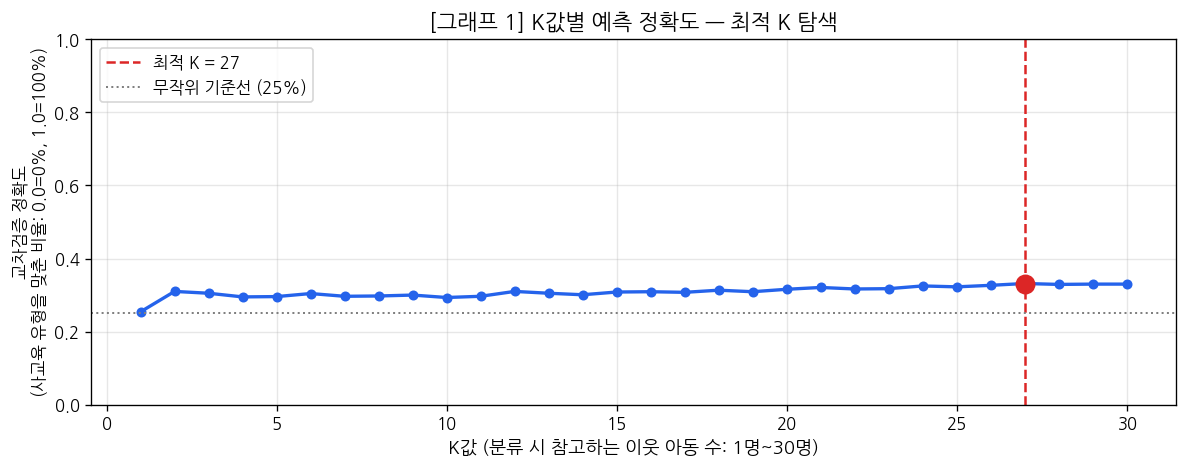

최적 K = 27  |  이때 교차검증 정확도 = 33.2%
참고) 무작위로 찍었을 때 기대 정확도 = 25.0% (4개 그룹 중 1개 선택)


In [ ]:
k_range = range(1, 31)
cv_scores = []

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_val_score(knn, X_train_sc, y_train, cv=kfold, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k   = list(k_range)[np.argmax(cv_scores)]
best_acc = max(cv_scores)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(list(k_range), cv_scores, 'o-', color='#2563EB', linewidth=2, markersize=5)
ax.axvline(best_k, color='#DC2626', linestyle='--', linewidth=1.5, label=f'최적 K = {best_k}')
ax.scatter([best_k], [best_acc], color='#DC2626', s=120, zorder=5)

# 축 레이블 설명
ax.set_xlabel('K값 (분류 시 참고하는 이웃 아동 수: 1명~30명)', fontsize=11)
ax.set_ylabel('교차검증 정확도\n(사교육 유형을 맞춘 비율: 0.0=0%, 1.0=100%)', fontsize=10)
ax.set_title('[그래프 1] K값별 예측 정확도 — 최적 K 탐색', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1)
ax.axhline(0.25, color='gray', linestyle=':', linewidth=1.2, label='무작위 기준선 (25%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'최적 K = {best_k}  |  이때 교차검증 정확도 = {best_acc*100:.1f}%')
print(f'참고) 무작위로 찍었을 때 기대 정확도 = 25.0% (4개 그룹 중 1개 선택)')


---
## Step 6. KNN 모델 학습 및 최종 정확도 확인
최적 K로 모델을 학습시키고, 한 번도 본 적 없는 테스트 데이터로 성능을 측정합니다.


In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train_sc, y_train)
y_pred = knn_best.predict(X_test_sc)

acc = accuracy_score(y_test, y_pred)
target_names = [label_map[i] for i in sorted(label_map)]

print('=' * 55)
print(f'  KNN 최종 테스트 정확도: {acc*100:.1f}%')
print(f'  (무작위 기준: 25.0% | 4개 그룹 중 1개를 찍는 경우)')
print('=' * 55)
print()
print('--- 그룹별 세부 성능 ---')
print('precision  = 이 그룹이라고 예측했을 때 실제로 맞은 비율')
print('recall     = 실제 이 그룹 아이를 맞게 분류한 비율')
print('f1-score   = precision과 recall의 균형 점수')
print()
print(classification_report(y_test, y_pred, target_names=target_names))


  KNN 최종 테스트 정확도: 30.3%
  (무작위 기준: 25.0% | 4개 그룹 중 1개를 찍는 경우)

--- 그룹별 세부 성능 ---
precision  = 이 그룹이라고 예측했을 때 실제로 맞은 비율
recall     = 실제 이 그룹 아이를 맞게 분류한 비율
f1-score   = precision과 recall의 균형 점수

              precision    recall  f1-score   support

       사교육없음       0.33      0.67      0.45       104
         학습만       0.21      0.08      0.11        63
        예체능만       0.26      0.12      0.17        74
      학습+예체능       0.22      0.12      0.15        59

    accuracy                           0.30       300
   macro avg       0.26      0.25      0.22       300
weighted avg       0.27      0.30      0.25       300



---
## Step 7. 혼동 행렬 — 어디서 틀렸는지 확인 (그래프 2)
모델이 어떤 그룹을 어떤 그룹으로 잘못 분류했는지 한눈에 보여줍니다.

**📌 그래프 읽는 법**
- **세로축(Y축, 실제 사교육 유형)**: 아이의 실제 사교육 유형 (정답)
- **가로축(X축, 예측된 사교육 유형)**: KNN 모델이 예측한 사교육 유형
- **대각선 칸 (↘방향)**: 정확히 맞춘 경우 → 숫자가 클수록 예측 성능이 좋음
- **대각선 바깥 칸**: 잘못 분류한 경우 → 숫자가 클수록 혼동이 많다는 뜻
- 색이 진할수록 해당 칸에 해당하는 아이가 많음
- **대각선 밖 칸에 숫자가 많이 퍼져 있다면** → 정서점수로 사교육 유형 구분이 안 된다는 의미


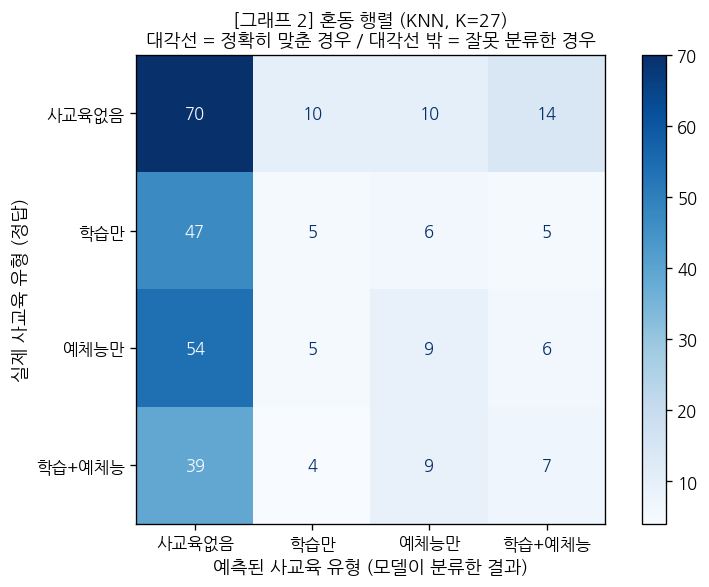

정확히 맞춘 비율(정분류율): 30.3%
잘못 분류한 비율(오분류율): 69.7%


In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title(f'[그래프 2] 혼동 행렬 (KNN, K={best_k})\n'
             '대각선 = 정확히 맞춘 경우 / 대각선 밖 = 잘못 분류한 경우',
             fontsize=11, fontweight='bold')
ax.set_ylabel('실제 사교육 유형 (정답)', fontsize=11)
ax.set_xlabel('예측된 사교육 유형 (모델이 분류한 결과)', fontsize=11)
plt.tight_layout()
plt.show()

diag_ratio = np.diag(cm).sum() / cm.sum()
print(f'정확히 맞춘 비율(정분류율): {diag_ratio*100:.1f}%')
print(f'잘못 분류한 비율(오분류율): {(1-diag_ratio)*100:.1f}%')


---
## Step 8. 사교육 유형별 정서점수 분포 시각화 (그래프 3)
5가지 정서·행동 점수를 2차원으로 압축(PCA)해서 그룹별 분포를 점으로 나타냅니다.

**📌 그래프 읽는 법**
- **가로축(X축, PC1)**: 5개 정서점수 전체를 요약한 첫 번째 방향 — 점수가 오른쪽일수록 정서·행동 문제가 다른 패턴
- **세로축(Y축, PC2)**: 5개 정서점수 전체를 요약한 두 번째 방향 — 점수가 위쪽일수록 또 다른 패턴
- **각 점**: 아동 1명의 정서발달 위치
- **색깔**: 사교육 유형 (회색=없음, 파랑=학습만, 초록=예체능만, 빨강=학습+예체능)
- **점들이 섞여서 구분이 안 된다면** → 정서점수만으로는 사교육 유형을 구별할 수 없다는 의미

※ PC1·PC2는 원래 점수를 그대로 쓰지 않고 수학적으로 변환한 값이므로 절댓값보다 **분포 모양(겹침 여부)** 이 중요합니다.


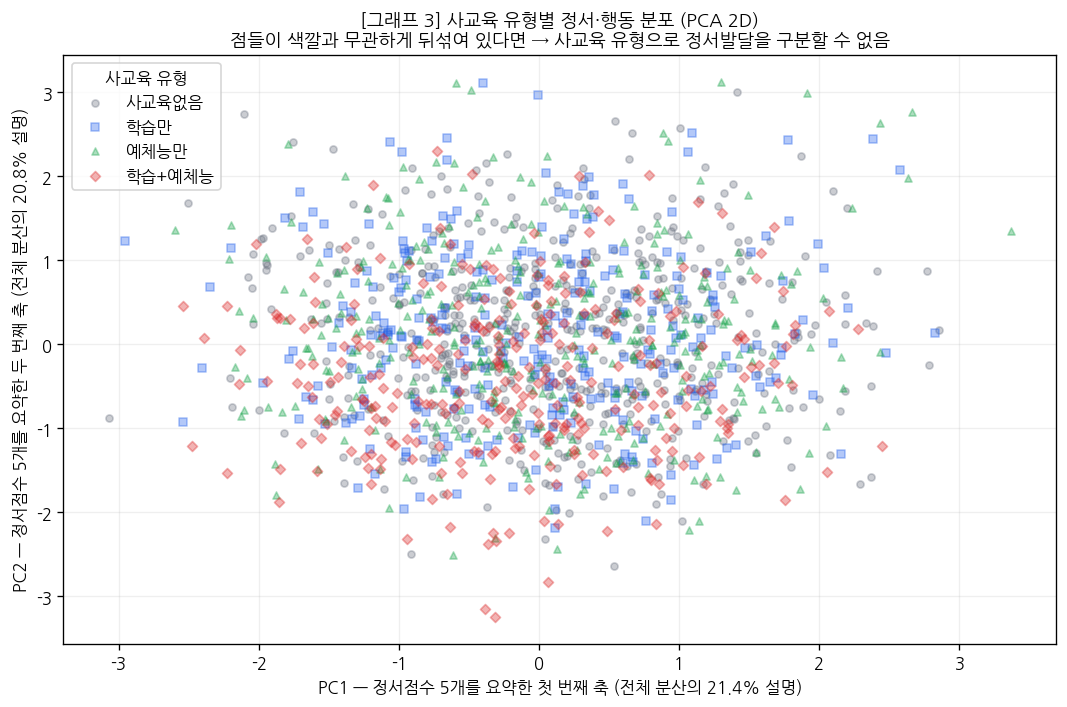

두 축으로 설명되는 정보량: 42.2%


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaler.transform(X))

colors  = ['#6B7280', '#2563EB', '#16A34A', '#DC2626']
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(9, 6))
for i, (label, name) in enumerate(label_map.items()):
    mask = y == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[i], marker=markers[i],
               alpha=0.35, s=18, label=name)

var_exp = pca.explained_variance_ratio_ * 100
ax.set_xlabel(
    f'PC1 — 정서점수 5개를 요약한 첫 번째 축 (전체 분산의 {var_exp[0]:.1f}% 설명)',
    fontsize=10)
ax.set_ylabel(
    f'PC2 — 정서점수 5개를 요약한 두 번째 축 (전체 분산의 {var_exp[1]:.1f}% 설명)',
    fontsize=10)
ax.set_title(
    '[그래프 3] 사교육 유형별 정서·행동 분포 (PCA 2D)\n'
    '점들이 색깔과 무관하게 뒤섞여 있다면 → 사교육 유형으로 정서발달을 구분할 수 없음',
    fontsize=11, fontweight='bold')
ax.legend(title='사교육 유형', fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f'두 축으로 설명되는 정보량: {sum(var_exp):.1f}%')


---
## Step 9. 사교육 유형별 정서점수 평균 비교 (그래프 4)
5가지 정서·행동 점수를 항목별로 막대그래프로 비교합니다.

**📌 그래프 읽는 법**
- **가로축(X축)**: 사교육 유형 4가지 그룹 (사교육없음 / 학습만 / 예체능만 / 학습+예체능)
- **세로축(Y축)**: 해당 정서·행동 점수의 평균값 (1~3점 만점)
  - 정서증상·또래문제·행동문제·과잉행동 → 점수가 높을수록 문제가 많음
  - 친사회적 행동 → 점수가 높을수록 긍정적(배려·협력)
- **막대 높이가 4개 그룹 간에 거의 같다면** → 사교육 유형과 해당 점수가 무관하다는 의미
- 막대 위 숫자: 각 그룹의 정확한 평균점수


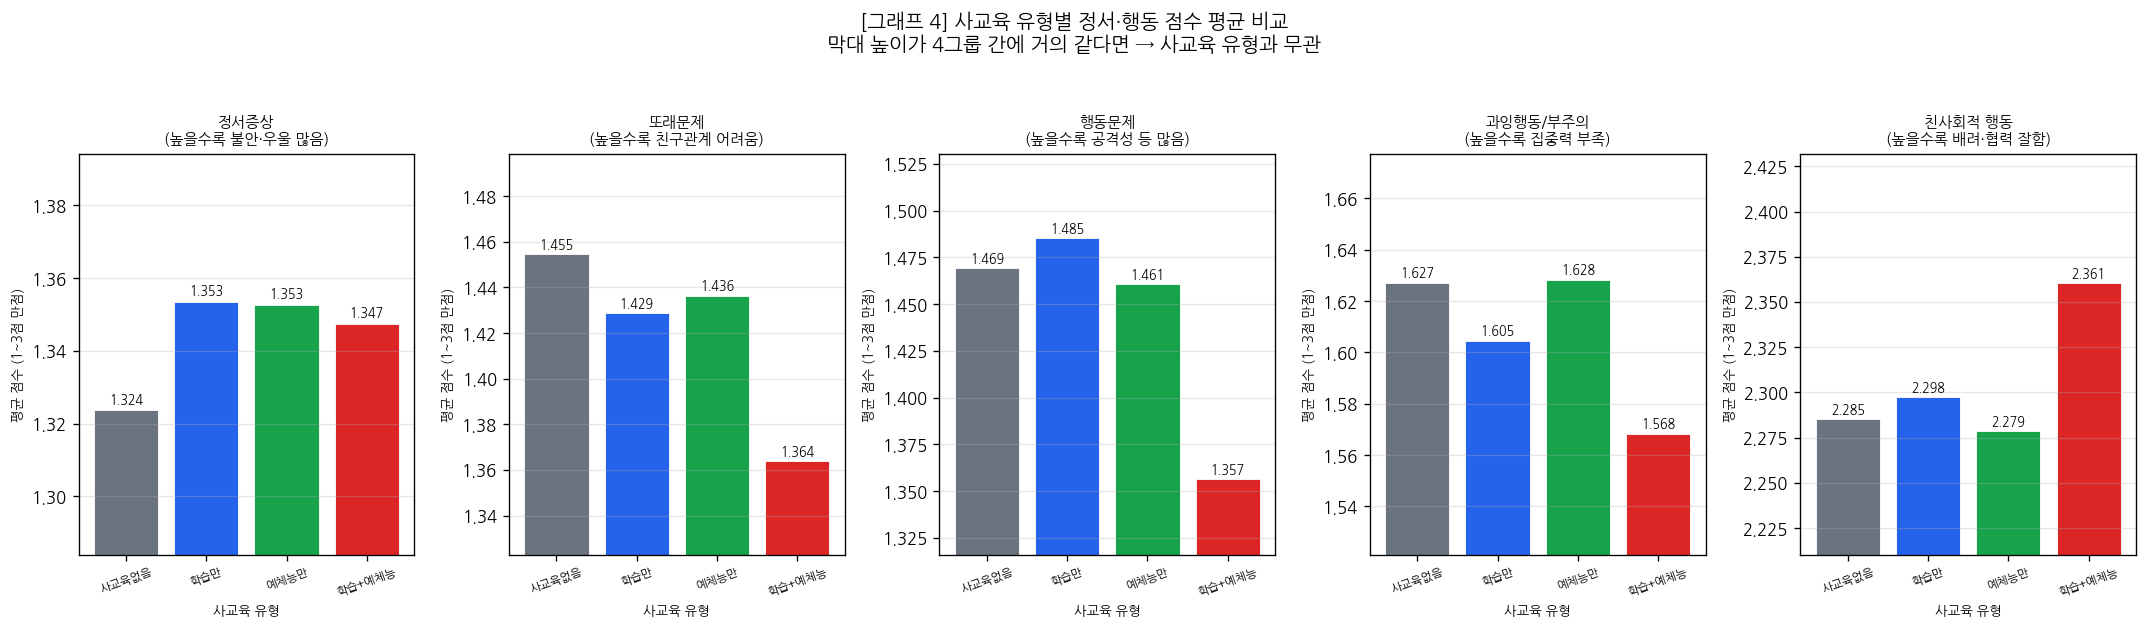

In [ ]:
means = data.groupby('사교육유형')[features].mean()
means.index = [label_map[i] for i in means.index]

colors_bar  = ['#6B7280', '#2563EB', '#16A34A', '#DC2626']
feat_titles = [
    '정서증상\n(높을수록 불안·우울 많음)',
    '또래문제\n(높을수록 친구관계 어려움)',
    '행동문제\n(높을수록 공격성 등 많음)',
    '과잉행동/부주의\n(높을수록 집중력 부족)',
    '친사회적 행동\n(높을수록 배려·협력 잘함)',
]

fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=False)

for ax, feat, title in zip(axes, features, feat_titles):
    vals = means[feat].values
    bars = ax.bar(means.index, vals, color=colors_bar, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylim(min(vals)*0.97, max(vals)*1.03)
    ax.set_xlabel('사교육 유형', fontsize=8)
    ax.set_ylabel('평균 점수 (1~3점 만점)', fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=20)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

fig.suptitle('[그래프 4] 사교육 유형별 정서·행동 점수 평균 비교\n'
             '막대 높이가 4그룹 간에 거의 같다면 → 사교육 유형과 무관',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()


---
## Step 10. 분석 결과 최종 정리


In [ ]:
print('=' * 60)
print('   📋 KNN 분석 최종 결과 요약')
print('=' * 60)

print(f'''
【 모델 성능 】
  최적 K값                : {best_k}
  교차검증 정확도 (학습 중) : {best_acc*100:.1f}%
  테스트 정확도 (최종 평가) : {acc*100:.1f}%
  무작위 기준 정확도       : 25.0%
  (4개 그룹 중 아무거나 찍었을 때 기대 정확도)

【 해석 】
  KNN 정확도가 {acc*100:.1f}%라는 것은,
  아이의 정서·행동 점수를 입력해도
  사교육 유형을 {acc*100:.1f}% 밖에 맞추지 못한다는 뜻입니다.

  이는 무작위로 찍는 것(25%)과 거의 차이가 없는 수준입니다.

【 각 정서점수의 집단 간 차이 】
  정서증상   최대-최소 차이: {data.groupby("사교육유형")["정서증상"].mean().max() - data.groupby("사교육유형")["정서증상"].mean().min():.3f}점
  또래문제   최대-최소 차이: {data.groupby("사교육유형")["또래문제"].mean().max() - data.groupby("사교육유형")["또래문제"].mean().min():.3f}점
  행동문제   최대-최소 차이: {data.groupby("사교육유형")["행동문제"].mean().max() - data.groupby("사교육유형")["행동문제"].mean().min():.3f}점
  과잉행동   최대-최소 차이: {data.groupby("사교육유형")["과잉행동"].mean().max() - data.groupby("사교육유형")["과잉행동"].mean().min():.3f}점
  친사회행동 최대-최소 차이: {data.groupby("사교육유형")["친사회적행동"].mean().max() - data.groupby("사교육유형")["친사회적행동"].mean().min():.3f}점
  → 모든 항목에서 4개 그룹 간 차이가 0.1점 이하로 극히 작음

【 결론 】
  ✅ 영유아 사교육 경험(유형·개수)과
     정서·행동 발달 사이에는
     의미 있는 관계가 존재하지 않습니다.

  이는 육아정책연구소(2024) 원 연구 결론과 일치합니다:
  "사교육 여부 및 개수에 따른 행동 특성에서
   세부적으로 거의 차이가 없는 것으로 나타남."
''')
print('=' * 60)


   📋 KNN 분석 최종 결과 요약

【 모델 성능 】
  최적 K값                : 27
  교차검증 정확도 (학습 중) : 33.2%
  테스트 정확도 (최종 평가) : 30.3%
  무작위 기준 정확도       : 25.0%
  (4개 그룹 중 아무거나 찍었을 때 기대 정확도)

【 해석 】
  KNN 정확도가 30.3%라는 것은,
  아이의 정서·행동 점수를 입력해도
  사교육 유형을 30.3% 밖에 맞추지 못한다는 뜻입니다.

  이는 무작위로 찍는 것(25%)과 거의 차이가 없는 수준입니다.

【 각 정서점수의 집단 간 차이 】
  정서증상   최대-최소 차이: 0.030점
  또래문제   최대-최소 차이: 0.091점
  행동문제   최대-최소 차이: 0.129점
  과잉행동   최대-최소 차이: 0.060점
  친사회행동 최대-최소 차이: 0.082점
  → 모든 항목에서 4개 그룹 간 차이가 0.1점 이하로 극히 작음

【 결론 】
  ✅ 영유아 사교육 경험(유형·개수)과
     정서·행동 발달 사이에는
     의미 있는 관계가 존재하지 않습니다.

  이는 육아정책연구소(2024) 원 연구 결론과 일치합니다:
  "사교육 여부 및 개수에 따른 행동 특성에서
   세부적으로 거의 차이가 없는 것으로 나타남."

